Point P:
  P = (5.000000, 5.000000)

Normal footpoints on the ellipse:
  Footpoint 1: (3.419197, 2.188898)
  Footpoint 2: (-4.681362, -1.053824)



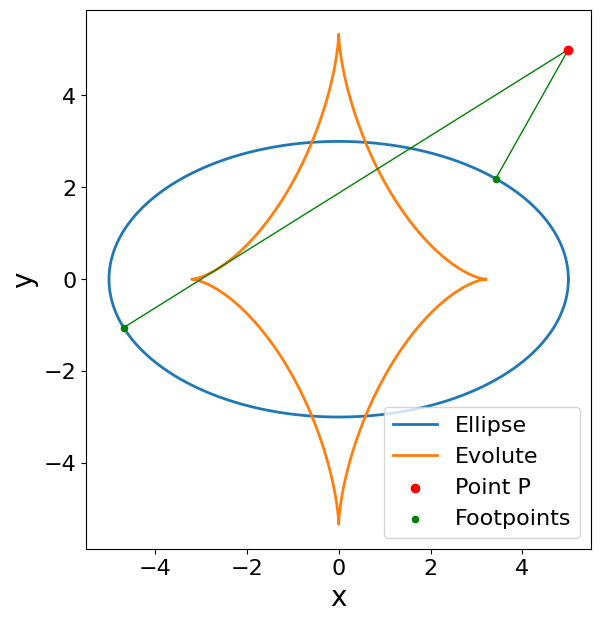

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Ellipse parameters
a, b = 5, 3

# Parametric ellipse
def r(t):
    return a*np.cos(t), b*np.sin(t)

# Tangent vector
def rprime(t):
    return -a*np.sin(t), b*np.cos(t)

# How to find normal points: (P - r(t)) · r'(t) = 0
def f(t, Px, Py):
    x, y = r(t)
    tx, ty = rprime(t)
    return (Px - x)*tx + (Py - y)*ty

# Find all distinct roots of f(t)=0
def normal_footpoints(Px, Py, N=10000):
    ts = np.linspace(0, 2*np.pi, N, endpoint=False)
    fs = f(ts, Px, Py)

    roots = []

    for i in range(N):
        t1, t2 = ts[i], ts[(i+1) % N]
        f1, f2 = fs[i], fs[(i+1) % N]

        if abs(f1) <  1e-6:
            root = t1
        elif f1*f2 < 0:
            # Bisection refinement
            a_t, b_t = t1, t2
            fa, fb = f1, f2
            for _ in range(40):
                m = 0.5*(a_t + b_t)
                fm = f(m, Px, Py)
                if fa*fm <= 0:
                    b_t, fb = m, fm
                else:
                    a_t, fa = m, fm
            root = 0.5*(a_t + b_t)
        else:
            continue

        # Normalise to [0, 2π)
        root = (root + 2*np.pi) % (2*np.pi)


        if not any(abs(root - r0) < 1e-3 for r0 in roots):
            roots.append(root)

    # Return the points on the ellipse that are normal
    xs, ys = [], []
    for t0 in roots:
        xi, yi = r(t0)
        xs.append(xi)
        ys.append(yi)
    return np.array(xs), np.array(ys)

# Plot ellipse and evolute
t_plot = np.linspace(0, 2*np.pi, 10000)
x_ell, y_ell = r(t_plot)
Xe = (a**2 - b**2)/a * np.cos(t_plot)**3
Ye = (b**2 - a**2)/b * np.sin(t_plot)**3

# Choose a point P
Px, Py = 5,5

print("Point P:")
print(f"  P = ({Px:.6f}, {Py:.6f})\n")

# Compute normals
nx, ny = normal_footpoints(Px, Py)

print("Normal footpoints on the ellipse:")
for i, (xi, yi) in enumerate(zip(nx, ny), start=1):
    print(f"  Footpoint {i}: ({xi:.6f}, {yi:.6f})")
print()

# Plot
plt.figure(figsize=(7,7))
plt.plot(x_ell, y_ell, lw=2, label="Ellipse")
plt.plot(Xe, Ye, lw=2, label="Evolute")
plt.scatter(Px, Py, color='red', zorder=5, label="Point P")

# Draw normals
for xi, yi in zip(nx, ny):
    plt.plot([Px, xi], [Py, yi], color='green', lw=1)

plt.scatter(nx, ny, color='green', zorder=6, s=20, label="Footpoints")

plt.gca().set_aspect("equal")
plt.legend(fontsize = 16)
plt.xlabel("x", fontsize = 20)
plt.ylabel("y", fontsize = 20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("normal_footpoints.pdf")
plt.show()

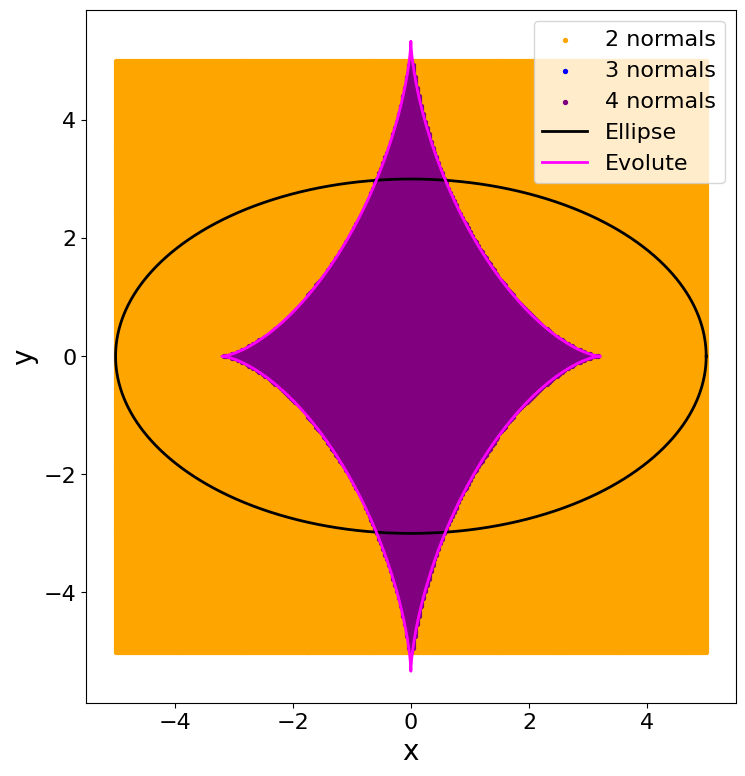

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Ellipse parameters
a, b = 5, 3

# Parametric ellipse
def r(t):
    return a*np.cos(t), b*np.sin(t)

# Tangent vector
def rprime(t):
    return -a*np.sin(t), b*np.cos(t)

# How to find normal points: (P - r(t)) · r'(t) = 0
def f(t, Px, Py):
    x, y = r(t)
    tx, ty = rprime(t)
    return (Px - x)*tx + (Py - y)*ty

# Count distinct roots of f(t)=0
def count_normals(Px, Py, N=5000):
    ts = np.linspace(0, 2*np.pi, N, endpoint=False)
    fs = f(ts, Px, Py)

    roots = []

    for i in range(N):
        t1, t2 = ts[i], ts[(i+1) % N]
        f1, f2 = fs[i], fs[(i+1) % N]

        if abs(f1) <  1e-6:
            root = t1
        elif f1*f2 < 0:
            # Bisection refinement
            a_t, b_t = t1, t2
            fa, fb = f1, f2
            for _ in range(40):
                m = 0.5*(a_t + b_t)
                fm = f(m, Px, Py)
                if fa*fm <= 0:
                    b_t, fb = m, fm
                else:
                    a_t, fa = m, fm
            root = 0.5*(a_t + b_t)
        else:
            continue

        # Normalise to [0, 2π)
        root = (root + 2*np.pi) % (2*np.pi)


        if not any(abs(root - r0) < 1e-3 for r0 in roots):
            roots.append(root)

    return len(roots)

# Evolute
t_plot = np.linspace(0, 2*np.pi, 2000)
Xe = (a*a - b*b)/a * np.cos(t_plot)**3
Ye = (b*b - a*a)/b * np.sin(t_plot)**3

# Grid
xs = np.linspace(-5, 5, 301)
ys = np.linspace(-5, 5, 301)

Px_list = []
Py_list = []
count_list = []

for Px in xs:
    for Py in ys:
        Px_list.append(Px)
        Py_list.append(Py)
        count_list.append(count_normals(Px, Py))

Px_list = np.array(Px_list)
Py_list = np.array(Py_list)
count_list = np.array(count_list)

# Colour map for 2–4 normals
colour_map = {
    2: "Orange",
    3: "blue",
    4: "Purple"
}

plt.figure(figsize=(9, 9))

# Scatter points by normal count
for c in [2, 3, 4]:
    mask = (count_list == c)
    plt.scatter(Px_list[mask], Py_list[mask], s=8,
                color=colour_map[c], label=f"{c} normals")

# Ellipse
x_ell, y_ell = r(t_plot)
plt.plot(x_ell, y_ell, "black", linewidth=2, label="Ellipse")

# Evolute
plt.plot(Xe, Ye, "magenta", linewidth=2, label="Evolute")

plt.gca().set_aspect("equal")
plt.xlabel("x", fontsize = 20)
plt.ylabel("y", fontsize = 20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize = 16)
plt.savefig("normal_count_regions.pdf")
plt.show()

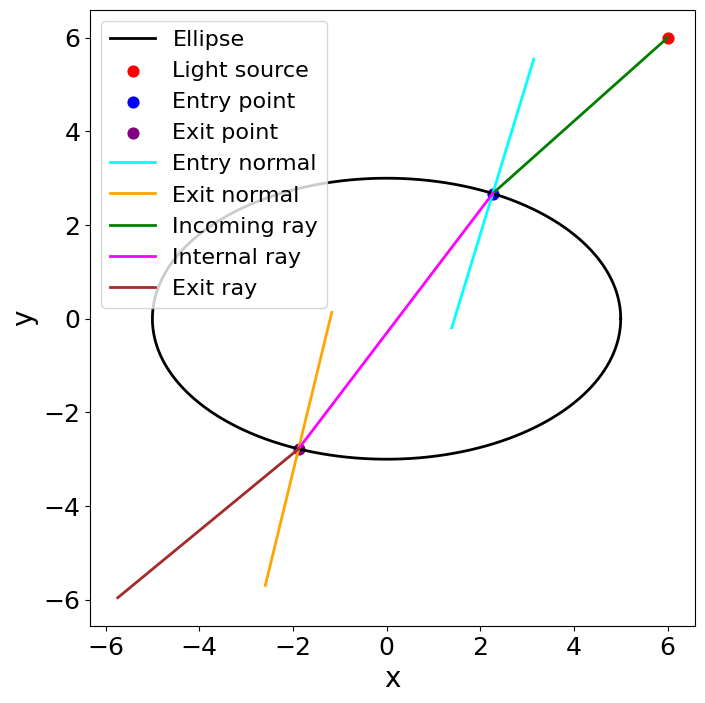

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ellipse parameters: x^2/a^2 + y^2/b^2 = 1
a, b = 5.0, 3.0

# Parametric ellipse
def r(t):
    return np.array([a*np.cos(t), b*np.sin(t)])

# Tangent vector
def rprime(t):
    return np.array([-a*np.sin(t), b*np.cos(t)])

# Outward unit normal
def unit_normal(t):
    tx, ty = rprime(t)
    nx, ny = ty, -tx
    L = np.hypot(nx, ny)
    return np.array([nx/L, ny/L])

# Refraction (snells law)
def refract(d_in, n, n1, n2):
    if np.dot(d_in, n) > 0:
        n = -n
    mu = n1 / n2
    cos_i = -np.dot(n, d_in)
    sin_t2 = mu**2 * (1 - cos_i**2)
    if sin_t2 > 1:
        return None  # if TIR occurs
    cos_t = np.sqrt(1 - sin_t2)
    return mu*d_in + (mu*cos_i - cos_t)*n

# Intersection of ray P + s d with ellipse
def intersect_ray_with_ellipse(P, d, s_min=1e-6):
    Px, Py = P
    dx, dy = d

    A = (dx*dx)/(a*a) + (dy*dy)/(b*b)
    B = 2*(Px*dx/(a*a) + Py*dy/(b*b))
    C = (Px*Px)/(a*a) + (Py*Py)/(b*b) - 1

    disc = B*B - 4*A*C
    if disc < 0:
        return None

    s1 = (-B + np.sqrt(disc)) / (2*A)
    s2 = (-B - np.sqrt(disc)) / (2*A)
    s_vals = [s for s in (s1, s2) if s > s_min]
    if not s_vals:
        return None

    return P + min(s_vals)*d

# Approximate parameter t for a point on ellipse
def find_t_for_point(X, Y):
    return np.arctan2(Y/b, X/a)


# Point of light starting
P_src = np.array([6, 6])

# Choose t0 to decide entry point
t0 = 1.1
Q1 = r(t0)

# Incoming direction
d_in = Q1 - P_src
d_in = d_in / np.linalg.norm(d_in)

# Normal at entry
n1 = unit_normal(t0)

# First refraction: air to glass
d_inside = refract(d_in, n1, 1.0, 1.5)

# Internal intersection with ellipse
Q2 = intersect_ray_with_ellipse(Q1, d_inside)

# Normal at exit
t2 = find_t_for_point(Q2[0], Q2[1])
n2 = unit_normal(t2)

# Second refraction: glass to air
d_out = refract(d_inside, n2, 1.5, 1.0)


# Plot
t_plot = np.linspace(0, 2*np.pi, 1000)
x_ell = a*np.cos(t_plot)
y_ell = b*np.sin(t_plot)

plt.figure(figsize=(8,8))
plt.plot(x_ell, y_ell, 'k', lw=2, label="Ellipse")

# Points
plt.scatter(P_src[0], P_src[1], color='red', s=60, label="Light source")
plt.scatter(Q1[0], Q1[1], color='blue', s=60, label="Entry point")
plt.scatter(Q2[0], Q2[1], color='purple', s=60, label="Exit point")

L = 3

plt.plot([Q1[0] - L*n1[0], Q1[0] + L*n1[0]],
         [Q1[1] - L*n1[1], Q1[1] + L*n1[1]],
         color='cyan', lw=2, label="Entry normal")

plt.plot([Q2[0] - L*n2[0], Q2[0] + L*n2[0]],
         [Q2[1] - L*n2[1], Q2[1] + L*n2[1]],
         color='orange', lw=2, label="Exit normal")


# Rays
plt.plot([P_src[0], Q1[0]], [P_src[1], Q1[1]],
         color='green', lw=2, label="Incoming ray")

plt.plot([Q1[0], Q2[0]], [Q1[1], Q2[1]],
         color='magenta', lw=2, label="Internal ray")

plt.plot([Q2[0], Q2[0] + d_out[0]*5],
         [Q2[1], Q2[1] + d_out[1]*5],
         color='brown', lw=2, label="Exit ray")

plt.gca().set_aspect("equal")
plt.xlabel("x", fontsize = 20)
plt.ylabel("y", fontsize = 20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize = 16, loc = 'upper left')
plt.savefig("beam_through_ellipse_normals.pdf")
plt.show()